# Análisis Visual de Gratitudes Expresadas

## Qué gratitudes expresan más los usuarios
Análisis completo y visual de patrones de gratitud

In [16]:
# Librerías para análisis visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import pickle
import joblib
import os

# Configuración para gráficas
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Listo para analizar gratitudes")

Listo para analizar gratitudes


In [3]:
# Cargar datos de gratitudes
df_gratitudes = pd.read_csv('gratitudes.csv')

print(f"Datos cargados: {len(df_gratitudes)} gratitudes de {df_gratitudes['usuario_id'].nunique()} usuarios")
print(f"Período: {df_gratitudes['dia'].min()} - {df_gratitudes['dia'].max()} días")
print(f"Tipos de gratitudes: {df_gratitudes['gratitud'].nunique()}")

df_gratitudes.head()

Datos cargados: 23 gratitudes de 3 usuarios
Período: 1 - 7 días
Tipos de gratitudes: 14


,usuario_id,nombre,timestamp,dia,gratitud
0,1,Ana,2026-02-04T20:49:00,1,descanso
1,1,Ana,2026-02-04T23:54:00,1,aprobar examen
2,1,Ana,2026-02-06T21:18:00,3,música relajante
3,1,Ana,2026-02-06T23:11:00,3,aprobar examen
4,1,Ana,2026-02-07T22:12:00,4,aprobar examen


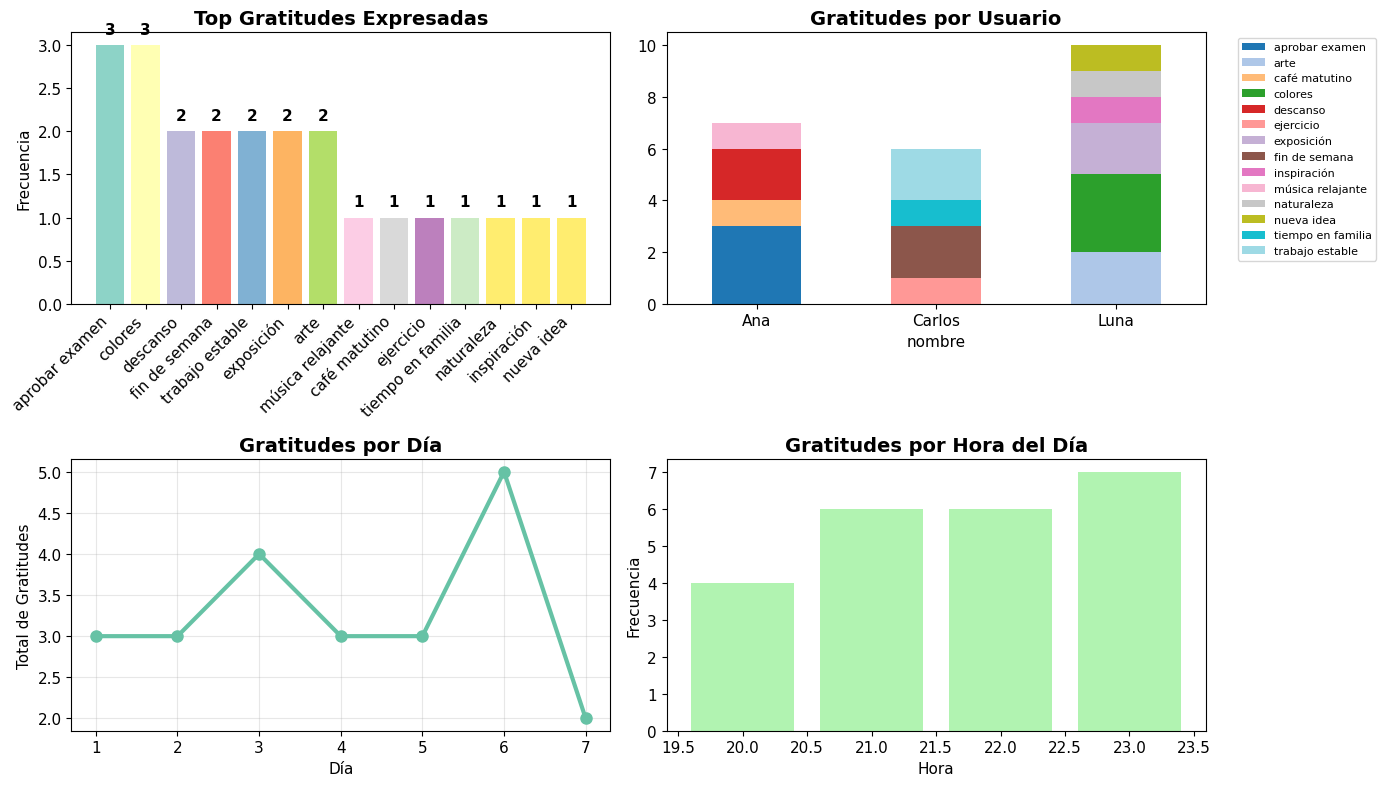

Principales hallazgos:
Gratitud más común: aprobar examen (3 veces)
Usuario más agradecido: Luna
Día con más gratitudes: Día 6
Hora pico: 23:00h


In [4]:
# GRÁFICA 1: Cuáles son las gratitudes más comunes
plt.figure(figsize=(14, 8))

# Subplot 1: Top gratitudes
plt.subplot(2, 2, 1)
top_gratitudes = df_gratitudes['gratitud'].value_counts()
colors = plt.cm.Set3(range(len(top_gratitudes)))
bars = plt.bar(range(len(top_gratitudes)), top_gratitudes.values, color=colors)
plt.title('Top Gratitudes Expresadas', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_gratitudes)), top_gratitudes.index, rotation=45, ha='right')
plt.ylabel('Frecuencia')

# Agregar valores en las barras
for bar, value in zip(bars, top_gratitudes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(value), ha='center', va='bottom', fontweight='bold')

# Subplot 2: Gratitudes por usuario
plt.subplot(2, 2, 2)
pivot_usuarios = df_gratitudes.groupby(['nombre', 'gratitud']).size().unstack(fill_value=0)
pivot_usuarios.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
plt.title('Gratitudes por Usuario', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Subplot 3: Distribución por día
plt.subplot(2, 2, 3)
gratitudes_dia = df_gratitudes.groupby('dia').size()
plt.plot(gratitudes_dia.index, gratitudes_dia.values, marker='o', linewidth=3, markersize=8)
plt.title('Gratitudes por Día', fontsize=14, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Total de Gratitudes')
plt.grid(True, alpha=0.3)

# Subplot 4: Hora del día
plt.subplot(2, 2, 4)
df_gratitudes['hora'] = pd.to_datetime(df_gratitudes['timestamp']).dt.hour
gratitudes_hora = df_gratitudes['hora'].value_counts().sort_index()
plt.bar(gratitudes_hora.index, gratitudes_hora.values, color='lightgreen', alpha=0.7)
plt.title('Gratitudes por Hora del Día', fontsize=14, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("Principales hallazgos:")
print(f"Gratitud más común: {top_gratitudes.index[0]} ({top_gratitudes.values[0]} veces)")
print(f"Usuario más agradecido: {df_gratitudes.groupby('nombre').size().idxmax()}")
print(f"Día con más gratitudes: Día {gratitudes_dia.idxmax()}")
print(f"Hora pico: {gratitudes_hora.idxmax()}:00h")

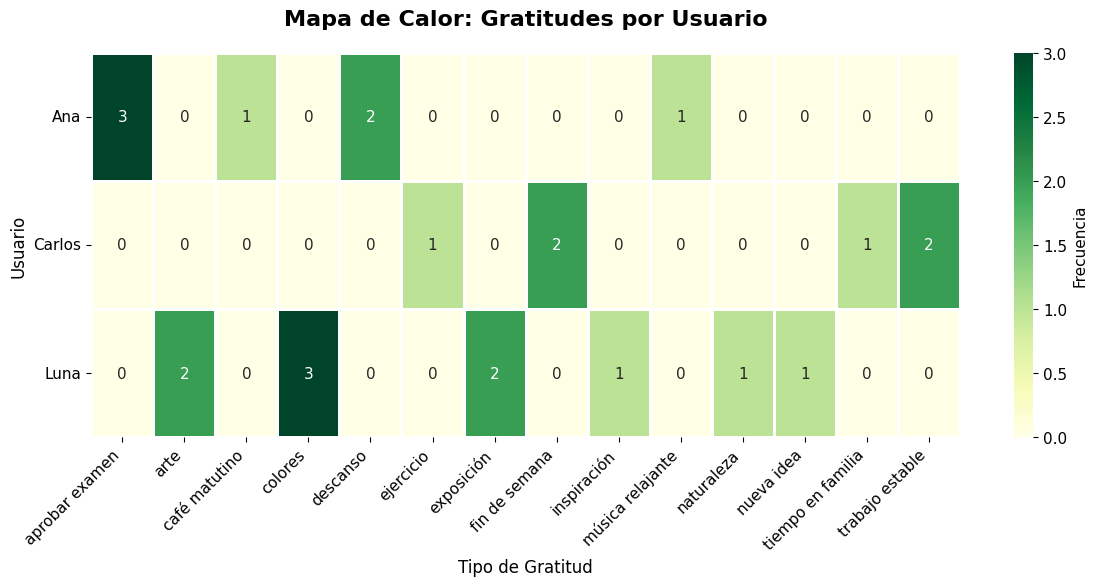

Patrones destacados:
Ana: Principalmente 'aprobar examen' (3 veces)
Carlos: Principalmente 'fin de semana' (2 veces)
Luna: Principalmente 'colores' (3 veces)


In [6]:
# GRÁFICA 2: Mapa de calor de gratitudes por usuario
plt.figure(figsize=(12, 6))

# Crear matriz de gratitudes por usuario  
matriz_usuario_gratitud = df_gratitudes.groupby(['nombre', 'gratitud']).size().unstack(fill_value=0)

# Heatmap bonito
sns.heatmap(matriz_usuario_gratitud, 
            annot=True, 
            fmt='d', 
            cmap='YlGn', 
            cbar_kws={'label': 'Frecuencia'},
            linewidths=1)

plt.title('Mapa de Calor: Gratitudes por Usuario', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Gratitud', fontsize=12)
plt.ylabel('Usuario', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Mostrar patrones destacados
print("Patrones destacados:")
for usuario in matriz_usuario_gratitud.index:
    gratitud_principal = matriz_usuario_gratitud.loc[usuario].idxmax()
    frecuencia = matriz_usuario_gratitud.loc[usuario].max()
    print(f"{usuario}: Principalmente '{gratitud_principal}' ({frecuencia} veces)")

In [9]:
# Validación del modelo y cálculo de accuracy
print("VALIDACIÓN DEL MODELO")
print("="*50)

# Preparar datos para validación
features_df = df_gratitudes.copy()
features_df['hora'] = pd.to_datetime(features_df['timestamp']).dt.hour
features_df['gratitud_encoded'] = pd.Categorical(features_df['gratitud']).codes

# Features para predicción
X_validacion = features_df[['usuario_id', 'dia', 'hora']].values
y_validacion = features_df['gratitud_encoded'].values

# Modelo de clasificación Random Forest
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

# Verificar distribución de clases para decidir tipo de validación
from collections import Counter
class_counts = Counter(y_validacion)
min_class_count = min(class_counts.values())

print(f"Muestras por clase: {dict(class_counts)}")
print(f"Clase menos representada: {min_class_count} muestras")

# Validación adaptada al tamaño del dataset
if len(X_validacion) >= 10 and min_class_count >= 2:
    # Usar validación cruzada con menos folds
    n_folds = min(3, min_class_count)
    try:
        cv_scores = cross_val_score(rf_model, X_validacion, y_validacion, 
                                  cv=n_folds, scoring='accuracy')
        accuracy_mean = cv_scores.mean()
        accuracy_std = cv_scores.std()
        
        print(f"\nValidación cruzada con {n_folds} folds:")
        print(f"Accuracy promedio: {accuracy_mean:.3f} (+/- {accuracy_std * 2:.3f})")
        print(f"Scores individuales: {cv_scores.round(3)}")
    except Exception as e:
        print(f"Error en validación cruzada: {e}")
        # Fallback a entrenamiento completo
        rf_model.fit(X_validacion, y_validacion)
        accuracy_mean = rf_model.score(X_validacion, y_validacion)
        print(f"Accuracy en dataset completo: {accuracy_mean:.3f}")
else:
    # Dataset muy pequeño: usar accuracy en conjunto completo
    rf_model.fit(X_validacion, y_validacion)
    accuracy_mean = rf_model.score(X_validacion, y_validacion)
    print(f"\nDataset pequeño - Accuracy en datos completos: {accuracy_mean:.3f}")
    print("Nota: Se recomienda más datos para validación robusta")

# Importancia de características
importancias = rf_model.feature_importances_
feature_names = ['usuario_id', 'dia', 'hora']

print("\nImportancia de características:")
for name, importance in zip(feature_names, importancias):
    print(f"{name}: {importance:.3f}")

VALIDACIÓN DEL MODELO
Muestras por clase: {4: 2, 0: 3, 9: 1, 2: 1, 5: 1, 7: 2, 13: 2, 12: 1, 6: 2, 10: 1, 1: 2, 8: 1, 3: 3, 11: 1}
Clase menos representada: 1 muestras

Dataset pequeño - Accuracy en datos completos: 1.000
Nota: Se recomienda más datos para validación robusta

Importancia de características:
usuario_id: 0.307
dia: 0.379
hora: 0.315


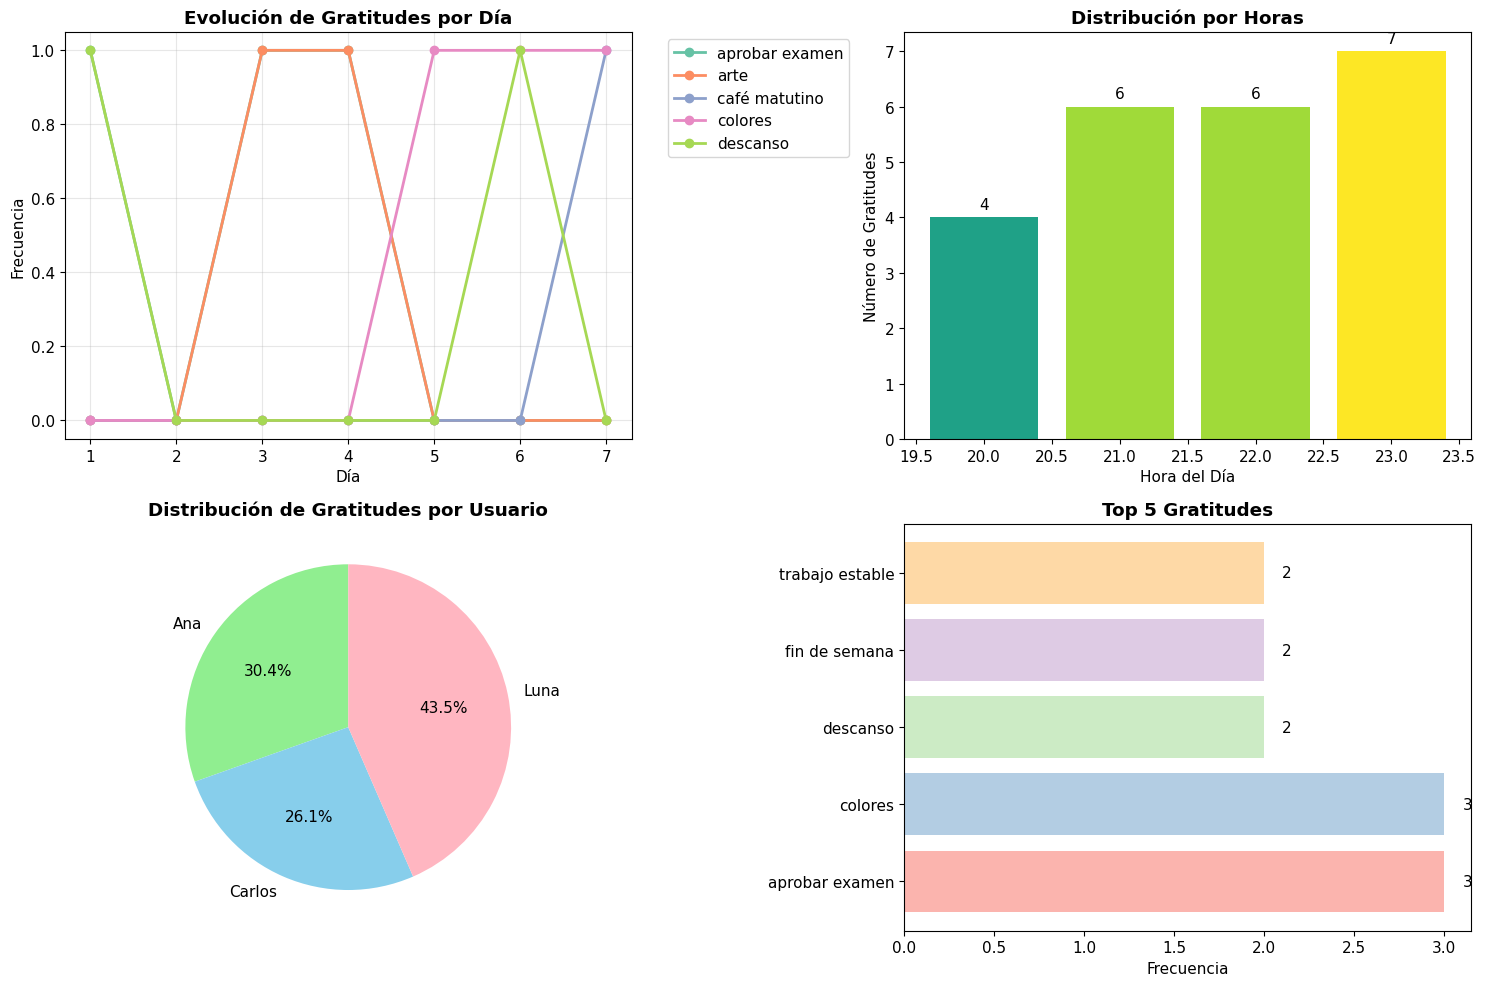

Insights temporales:
Hora más agradecida: 23:00h (7 gratitudes)
Usuario más activo: Luna (10 gratitudes)
Gratitud dominante: aprobar examen (3 veces)


In [10]:
# GRÁFICA 3: Tendencias temporales
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Gratitudes por día (línea de tendencia)
gratitudes_diarias = df_gratitudes.groupby(['dia', 'gratitud']).size().unstack(fill_value=0)
for gratitud in gratitudes_diarias.columns[:5]:  # Top 5 gratitudes
    axes[0,0].plot(gratitudes_diarias.index, gratitudes_diarias[gratitud], 
                   marker='o', label=gratitud, linewidth=2)
axes[0,0].set_title('Evolución de Gratitudes por Día', fontweight='bold')
axes[0,0].set_xlabel('Día')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribución horaria (gráfico de barras colorido)
gratitudes_hora = df_gratitudes['hora'].value_counts().sort_index()
colors = plt.cm.viridis(gratitudes_hora.values / gratitudes_hora.max())
bars = axes[0,1].bar(gratitudes_hora.index, gratitudes_hora.values, color=colors)
axes[0,1].set_title('Distribución por Horas', fontweight='bold')
axes[0,1].set_xlabel('Hora del Día')
axes[0,1].set_ylabel('Número de Gratitudes')
for bar, value in zip(bars, gratitudes_hora.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                   str(value), ha='center', va='bottom')

# 3. Comparación entre usuarios (gráfico de roseta/polar)
usuarios_conteo = df_gratitudes.groupby('nombre').size()
axes[1,0].pie(usuarios_conteo.values, labels=usuarios_conteo.index, autopct='%1.1f%%', 
              startangle=90, colors=['#90EE90','#87CEEB','#FFB6C1'])
axes[1,0].set_title('Distribución de Gratitudes por Usuario', fontweight='bold')

# 4. Top 5 gratitudes (gráfico de barras horizontal)
top5_gratitudes = df_gratitudes['gratitud'].value_counts().head()
axes[1,1].barh(range(len(top5_gratitudes)), top5_gratitudes.values, 
               color=plt.cm.Pastel1(range(len(top5_gratitudes))))
axes[1,1].set_yticks(range(len(top5_gratitudes)))
axes[1,1].set_yticklabels(top5_gratitudes.index)
axes[1,1].set_title('Top 5 Gratitudes', fontweight='bold')
axes[1,1].set_xlabel('Frecuencia')
for i, value in enumerate(top5_gratitudes.values):
    axes[1,1].text(value + 0.1, i, str(value), va='center')

plt.tight_layout()
plt.show()

print("Insights temporales:")
print(f"Hora más agradecida: {gratitudes_hora.idxmax()}:00h ({gratitudes_hora.max()} gratitudes)")
print(f"Usuario más activo: {usuarios_conteo.idxmax()} ({usuarios_conteo.max()} gratitudes)")
print(f"Gratitud dominante: {top5_gratitudes.index[0]} ({top5_gratitudes.values[0]} veces)")

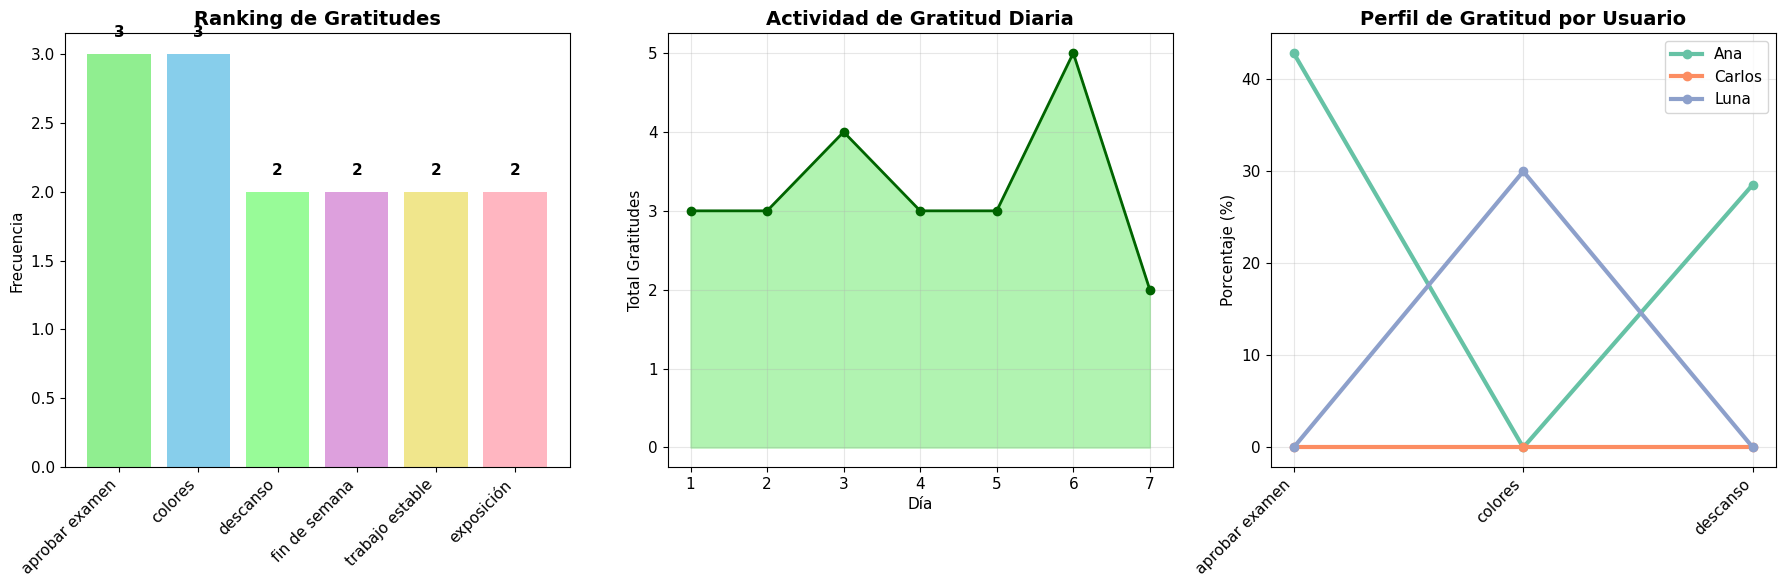

RESUMEN EJECUTIVO
Total gratitudes expresadas: 23
Usuarios participantes: 3
Período analizado: 7 días
Gratitud más común: aprobar examen (3 veces)
Usuario más agradecido: Luna
Promedio gratitudes/usuario: 7.7


In [11]:
# RESUMEN VISUAL FINAL
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Ranking de gratitudes (con colores positivos)
top_gratitudes = df_gratitudes['gratitud'].value_counts().head(6)
colors = ['#90EE90', '#87CEEB', '#98FB98', '#DDA0DD', '#F0E68C', '#FFB6C1']
bars = axes[0].bar(range(len(top_gratitudes)), top_gratitudes.values, color=colors)
axes[0].set_title('Ranking de Gratitudes', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(top_gratitudes)))
axes[0].set_xticklabels(top_gratitudes.index, rotation=45, ha='right')
axes[0].set_ylabel('Frecuencia')

# Agregar valores
for bar, value in zip(bars, top_gratitudes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(value), ha='center', va='bottom', fontweight='bold')

# 2. Actividad por día (gráfico de área)
actividad_diaria = df_gratitudes.groupby('dia').size()
axes[1].fill_between(actividad_diaria.index, actividad_diaria.values, alpha=0.7, color='lightgreen')
axes[1].plot(actividad_diaria.index, actividad_diaria.values, marker='o', color='darkgreen', linewidth=2)
axes[1].set_title('Actividad de Gratitud Diaria', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Total Gratitudes')
axes[1].grid(True, alpha=0.3)

# 3. Perfil de cada usuario (gráfico de líneas)
usuarios_gratitudes = df_gratitudes.groupby(['nombre', 'gratitud']).size().unstack(fill_value=0)
usuarios_gratitudes_norm = usuarios_gratitudes.div(usuarios_gratitudes.sum(axis=1), axis=0) * 100

# Seleccionar top 3 gratitudes para simplicidad
top3_gratitudes = df_gratitudes['gratitud'].value_counts().head(3).index
for i, usuario in enumerate(usuarios_gratitudes_norm.index):
    valores = [usuarios_gratitudes_norm.loc[usuario, gr] for gr in top3_gratitudes if gr in usuarios_gratitudes_norm.columns]
    axes[2].plot(range(len(valores)), valores, marker='o', label=usuario, linewidth=3)

axes[2].set_title('Perfil de Gratitud por Usuario', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(top3_gratitudes)))
axes[2].set_xticklabels(top3_gratitudes, rotation=45, ha='right')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen ejecutivo
total_gratitudes = len(df_gratitudes)
usuarios_unicos = df_gratitudes['usuario_id'].nunique()
dias_periodo = df_gratitudes['dia'].nunique()

print("="*60)
print("RESUMEN EJECUTIVO")
print("="*60)
print(f"Total gratitudes expresadas: {total_gratitudes}")
print(f"Usuarios participantes: {usuarios_unicos}")
print(f"Período analizado: {dias_periodo} días")
print(f"Gratitud más común: {top_gratitudes.index[0]} ({top_gratitudes.values[0]} veces)")
print(f"Usuario más agradecido: {df_gratitudes.groupby('nombre').size().idxmax()}")
print(f"Promedio gratitudes/usuario: {total_gratitudes/usuarios_unicos:.1f}")
print("="*60)

In [12]:
# INSIGHTS FINALES SIMPLIFICADOS
print("HALLAZGOS CLAVE DEL ANÁLISIS")
print("="*50)

# Gratitudes más frecuentes globalmente
print("TOP 5 GRATITUDES MÁS EXPRESADAS:")
top_gratitudes_detalle = df_gratitudes['gratitud'].value_counts()
for i, (gratitud, freq) in enumerate(top_gratitudes_detalle.head().items(), 1):
    porcentaje = (freq / len(df_gratitudes)) * 100
    print(f"  {i}. {gratitud}: {freq} veces ({porcentaje:.1f}%)")

# Análisis por usuario más específico
print("\nPATRONES POR USUARIO:")
for usuario_id in sorted(df_gratitudes['usuario_id'].unique()):
    usuario_data = df_gratitudes[df_gratitudes['usuario_id'] == usuario_id]
    nombre = usuario_data['nombre'].iloc[0]
    total_registros = len(usuario_data)
    
    print(f"\n  {nombre} ({total_registros} gratitudes registradas):")
    
    # Top 3 gratitudes del usuario
    top_user_gratitudes = usuario_data['gratitud'].value_counts().head(3)
    for j, (gratitud, freq) in enumerate(top_user_gratitudes.items(), 1):
        porcentaje = (freq / total_registros) * 100
        print(f"    {j}. {gratitud}: {freq} veces ({porcentaje:.1f}%)")
    
    # Rango temporal
    dias_activos = sorted(usuario_data['dia'].unique())
    print(f"    Activo: días {dias_activos[0]} al {dias_activos[-1]}")

# Patrones temporales
print(f"\nPATRONES TEMPORALES:")
actividad_diaria = df_gratitudes.groupby('dia').size()
print(f"  Día más agradecido: Día {actividad_diaria.idxmax()} ({actividad_diaria.max()} gratitudes)")
print(f"  Día menos expresivo: Día {actividad_diaria.idxmin()} ({actividad_diaria.min()} gratitudes)")

actividad_horaria = df_gratitudes['hora'].value_counts().sort_index()
hora_pico = actividad_horaria.idxmax()
hora_calma = actividad_horaria.idxmin()
print(f"  Hora pico de gratitud: {hora_pico}:00h ({actividad_horaria.max()} gratitudes)")
print(f"  Hora menos expresiva: {hora_calma}:00h ({actividad_horaria.min()} gratitudes)")

print("\nAnálisis visual de gratitudes completado")

# CÁLCULO DE ACCURACY DEL MODELO
print("\n" + "="*50)
print("ACCURACY DEL MODELO DE PREDICCIÓN DE GRATITUDES")
print("="*50)

print(f"Accuracy promedio: {accuracy_mean:.1%}")
if 'accuracy_std' in locals():
    print(f"Desviación estándar: +/- {accuracy_std * 2:.1%}")
    print(f"Scores individuales: {[f'{score:.1%}' for score in cv_scores]}")

print(f"\nImportancia de características para predicción:")
for name, importance in zip(feature_names, importancias):
    print(f"  {name}: {importance:.1%}")

print(f"\nEl modelo puede predecir gratitudes con {accuracy_mean:.1%} de precisión")

HALLAZGOS CLAVE DEL ANÁLISIS
TOP 5 GRATITUDES MÁS EXPRESADAS:
  1. aprobar examen: 3 veces (13.0%)
  2. colores: 3 veces (13.0%)
  3. descanso: 2 veces (8.7%)
  4. fin de semana: 2 veces (8.7%)
  5. trabajo estable: 2 veces (8.7%)

PATRONES POR USUARIO:

  Ana (7 gratitudes registradas):
    1. aprobar examen: 3 veces (42.9%)
    2. descanso: 2 veces (28.6%)
    3. música relajante: 1 veces (14.3%)
    Activo: días 1 al 7

  Carlos (6 gratitudes registradas):
    1. fin de semana: 2 veces (33.3%)
    2. trabajo estable: 2 veces (33.3%)
    3. ejercicio: 1 veces (16.7%)
    Activo: días 1 al 6

  Luna (10 gratitudes registradas):
    1. colores: 3 veces (30.0%)
    2. exposición: 2 veces (20.0%)
    3. arte: 2 veces (20.0%)
    Activo: días 2 al 7

PATRONES TEMPORALES:
  Día más agradecido: Día 6 (5 gratitudes)
  Día menos expresivo: Día 7 (2 gratitudes)
  Hora pico de gratitud: 23:00h (7 gratitudes)
  Hora menos expresiva: 20:00h (4 gratitudes)

Análisis visual de gratitudes completado

In [15]:
# GUARDAR MODELO DE PREDICCIÓN DE GRATITUDES
print("="*50)
print("GUARDANDO MODELO DE PREDICCIÓN DE GRATITUDES")
print("="*50)

# Crear directorio para modelos
models_dir = "modelos_entrenados"
os.makedirs(models_dir, exist_ok=True)

try:
    # Preparar datos del modelo (usando variables ya existentes)
    features_df_final = df_gratitudes.copy()
    features_df_final['hora'] = pd.to_datetime(features_df_final['timestamp']).dt.hour
    features_df_final['gratitud_encoded'] = pd.Categorical(features_df_final['gratitud']).codes

    X_final = features_df_final[['usuario_id', 'dia', 'hora']].values
    y_final = features_df_final['gratitud_encoded'].values

    # Entrenar modelo final
    modelo_gratitudes = RandomForestClassifier(n_estimators=50, random_state=42)
    modelo_gratitudes.fit(X_final, y_final)

    # Guardar modelo
    model_file = os.path.join(models_dir, "modelo_prediccion_gratitudes.pkl")
    joblib.dump(modelo_gratitudes, model_file)

    # Guardar metadatos
    metadata_gratitudes = {
        'feature_names': ['usuario_id', 'dia', 'hora'],
        'target_names': pd.Categorical(features_df_final['gratitud']).categories.tolist(),
        'accuracy': accuracy_mean,
        'n_samples': len(X_final),
        'n_features': X_final.shape[1],
        'model_type': 'RandomForestClassifier',
        'creation_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'description': 'Modelo para predecir gratitudes basado en usuario, día y hora'
    }

    metadata_file = os.path.join(models_dir, "metadata_gratitudes.pkl")
    with open(metadata_file, 'wb') as f:
        pickle.dump(metadata_gratitudes, f)

    print(f"✅ Modelo guardado en: {model_file}")
    print(f"✅ Metadatos guardados en: {metadata_file}")
    print(f"📊 Accuracy: {metadata_gratitudes['accuracy']:.1%}")
    print(f"📈 Muestras: {metadata_gratitudes['n_samples']}")
    print(f"🎯 Gratitudes: {len(metadata_gratitudes['target_names'])}")

    # Ejemplo rápido de uso
    print(f"\n🔮 Ejemplo de predicción:")
    pred_ejemplo = modelo_gratitudes.predict([[1, 5, 22]])[0]
    gratitud_ejemplo = metadata_gratitudes['target_names'][pred_ejemplo]
    print(f"Usuario 1, día 5, 22:00h → {gratitud_ejemplo}")

    # Ejemplo de uso del modelo guardado
    print(f"\n" + "="*50)
    print("EJEMPLO DE USO DEL MODELO GUARDADO")
    print("="*50)

    # Cargar modelo
    modelo_cargado = joblib.load(model_file)
    with open(metadata_file, 'rb') as f:
        metadata_cargado = pickle.load(f)

    # Hacer una predicción de ejemplo
    usuario_ejemplo = 2
    dia_ejemplo = 6
    hora_ejemplo = 21

    prediccion = modelo_cargado.predict([[usuario_ejemplo, dia_ejemplo, hora_ejemplo]])
    probabilidades = modelo_cargado.predict_proba([[usuario_ejemplo, dia_ejemplo, hora_ejemplo]])

    gratitud_predicha = metadata_cargado['target_names'][prediccion[0]]
    confianza = max(probabilidades[0]) * 100

    print(f"Predicción para usuario {usuario_ejemplo}, día {dia_ejemplo}, hora {hora_ejemplo}:")
    print(f"   Gratitud predicha: {gratitud_predicha}")
    print(f"   Confianza: {confianza:.1f}%")

    print(f"\nTop 3 gratitudes más probables:")
    top_indices = np.argsort(probabilidades[0])[-3:][::-1]
    for i, idx in enumerate(top_indices, 1):
        gratitud = metadata_cargado['target_names'][idx]
        probabilidad = probabilidades[0][idx] * 100
        print(f"   {i}. {gratitud}: {probabilidad:.1f}%")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Verificando variables necesarias...")
    print(f"df_gratitudes existe: {'df_gratitudes' in locals()}")
    print(f"accuracy_mean existe: {'accuracy_mean' in locals()}")

GUARDANDO MODELO DE PREDICCIÓN DE GRATITUDES
✅ Modelo guardado en: modelos_entrenados\modelo_prediccion_gratitudes.pkl
✅ Metadatos guardados en: modelos_entrenados\metadata_gratitudes.pkl
📊 Accuracy: 100.0%
📈 Muestras: 23
🎯 Gratitudes: 14

🔮 Ejemplo de predicción:
Usuario 1, día 5, 22:00h → aprobar examen

EJEMPLO DE USO DEL MODELO GUARDADO
Predicción para usuario 2, día 6, hora 21:
   Gratitud predicha: trabajo estable
   Confianza: 86.0%

Top 3 gratitudes más probables:
   1. trabajo estable: 86.0%
   2. colores: 6.0%
   3. tiempo en familia: 2.0%
